# Segment & Volume-Tier Analysis

Disaggregated evaluation of all forecasting methods on the test set (Jan–Sep 2020).

**Dimensions analysed:**
- Customer segment: Ladieswear, Menswear, Divided, Baby/Children, Sport
- Volume tier: Low (≤ median training sales), Medium (median–Q90), High (> Q90)

**Goal:** show whether ML gains are uniform across segments or concentrated in specific groups, strengthening the managerial interpretation of the Results chapter.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
os.makedirs('plots/segments', exist_ok=True)

BASE      = '/Users/kamilaya/Desktop/thesis'
TRAIN_END = '2019-04-30'
VAL_END   = '2019-12-31'


In [2]:
# ── Load unscaled full grid (for baseline predictions & labels) ───────────────
df = pd.read_csv(f'{BASE}/tshirts_preprocessed.csv', parse_dates=['week_start'])
df = df.sort_values(['article_id', 'week_start']).reset_index(drop=True)

train_df = df[df['week_start'] <= TRAIN_END].copy()
test_df  = df[df['week_start'] >  VAL_END].copy()

# ── Scaled test split (for ML model inference) ────────────────────────────────
test_scaled = pd.read_csv(f'{BASE}/tshirts_test.csv', parse_dates=['week_start'])
test_scaled = test_scaled.sort_values(['article_id', 'week_start']).reset_index(drop=True)

print(f'Unscaled test rows : {len(test_df):,}')
print(f'Scaled  test rows  : {len(test_scaled):,}')
assert len(test_df) == len(test_scaled), 'Row count mismatch — check sort order'


Unscaled test rows : 299,174
Scaled  test rows  : 299,174


In [3]:
# ── Reconstruct customer segment from OHE columns ────────────────────────────
SEG_COLS = [c for c in df.columns if c.startswith('index_group_name_')]
# Reference category (all OHE = 0) → Baby/Children
def get_segment(row):
    for col in SEG_COLS:
        if row[col] == 1:
            return col.replace('index_group_name_', '')
    return 'Baby/Children'

test_df = test_df.copy()
test_df['segment'] = test_df[SEG_COLS].apply(get_segment, axis=1)

print('Test rows per segment:')
print(test_df['segment'].value_counts().to_string())

# ── Volume tier based on mean training sales per article ──────────────────────
art_train_mean = (
    train_df.groupby('article_id')['weekly_sales_volume']
    .mean()
    .rename('train_mean_sales')
)
Q50 = art_train_mean.quantile(0.50)   # ≈ 0.091
Q90 = art_train_mean.quantile(0.90)   # ≈ 6.24

def volume_tier(mean_sales):
    if mean_sales <= Q50: return 'Low  (≤ Q50)'
    if mean_sales <= Q90: return 'Medium  (Q50–Q90)'
    return 'High  (> Q90)'

test_df = test_df.merge(art_train_mean.reset_index(), on='article_id', how='left')
test_df['volume_tier'] = test_df['train_mean_sales'].apply(volume_tier)

print(f'\nVolume tier thresholds:  Q50={Q50:.3f}  Q90={Q90:.3f} weekly units (training mean)')
print('\nTest rows per volume tier:')
print(test_df['volume_tier'].value_counts().to_string())


Test rows per segment:
segment
Baby/Children    128326
Menswear          57152
Ladieswear        53428
Divided           41040
Sport             19228

Volume tier thresholds:  Q50=0.091  Q90=6.236 weekly units (training mean)

Test rows per volume tier:
volume_tier
Low  (≤ Q50)         151810
Medium  (Q50–Q90)    117420
High  (> Q90)         29944


In [4]:
# ── Metric helpers ────────────────────────────────────────────────────────────
def rmse(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return np.sqrt(np.mean((a - b) ** 2))

def mae(a, b):
    a, b = np.asarray(a), np.asarray(b)
    return np.mean(np.abs(a - b))

def nz_mape(a, b):
    a, b = np.asarray(a), np.asarray(b)
    mask = a > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((a[mask] - b[mask]) / a[mask])) * 100

def metrics(label, y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return {
        'Method'     : label,
        'RMSE'       : round(rmse(y_true, y_pred),    4),
        'MAE'        : round(mae(y_true, y_pred),     4),
        'NZ-MAPE (%)': round(nz_mape(y_true, y_pred), 2),
    }


In [5]:
# ── Baseline predictions (computed on unscaled test_df) ──────────────────────
y_actual = test_df['weekly_sales_volume'].values

# 1. Naïve
naive_pred = test_df['sales_lag1'].values

# 2. MA-4
ma4_pred = test_df['sales_rolling4_mean'].values

# 3. Seasonal MA (MA-4 + SWLY)
history = df[df['week_start'] <= VAL_END][
    ['article_id', 'week_of_year', 'year', 'weekly_sales_volume']].copy()
swly_lookup = (
    history.groupby(['article_id', 'year', 'week_of_year'])['weekly_sales_volume']
    .mean().reset_index()
    .rename(columns={'year': 'lookup_year', 'weekly_sales_volume': 'swly_sales'})
)
art_mean_fb = (train_df.groupby('article_id')['weekly_sales_volume']
               .mean().rename('article_mean').reset_index())

def add_swly(pred_df, up_to):
    lk = swly_lookup[swly_lookup['lookup_year'] <= up_to]
    m  = pred_df[['article_id', 'week_of_year', 'year']].copy()
    m['lookup_year'] = m['year'] - 1
    m  = m.merge(lk, on=['article_id', 'week_of_year', 'lookup_year'], how='left')
    m  = m.merge(art_mean_fb, on='article_id', how='left')
    return m['swly_sales'].fillna(m['article_mean']).fillna(0).values

swly_test = add_swly(test_df, 2019)
sma_pred  = (ma4_pred + swly_test) / 2

# 4. Croston's method
def croston_fit(series, alpha=0.1, beta=0.1):
    series = np.asarray(series, float)
    nz = np.where(series > 0)[0]
    if len(nz) == 0: return 0.0, 1.0
    z, p = series[nz[0]], float(nz[0] + 1)
    for k in range(1, len(nz)):
        z = alpha * series[nz[k]] + (1 - alpha) * z
        p = beta  * (nz[k] - nz[k-1]) + (1 - beta) * p
    return z, p

def build_croston(train, pred):
    fc = {aid: croston_fit(g.sort_values('week_start')['weekly_sales_volume'].values)
          for aid, g in train.groupby('article_id')}
    gm = train['weekly_sales_volume'].mean()
    return np.clip(
        pred['article_id'].map(
            lambda a: fc[a][0] / fc[a][1] if a in fc and fc[a][1] > 0 else gm
        ).fillna(gm).values, 0, None)

train_val_df  = df[df['week_start'] <= VAL_END].copy()
croston_pred  = build_croston(train_val_df, test_df)

print('Baseline predictions ready.')
for name, pred in [('Naïve', naive_pred), ('MA-4', ma4_pred),
                   ('Seasonal MA', sma_pred), ("Croston", croston_pred)]:
    print(f'  {name:15s}  RMSE={rmse(y_actual, np.clip(pred,0,None)):.4f}')


Baseline predictions ready.
  Naïve            RMSE=6.6678
  MA-4             RMSE=7.8034
  Seasonal MA      RMSE=10.6762
  Croston          RMSE=12.6561


In [6]:
# ── ML model predictions ──────────────────────────────────────────────────────
# Re-use the same column-format auto-detection as baselines.ipynb cell 14
_OHE_PREFIXES = ('index_group_name_', 'colour_group_name_',
                 'graphical_appearance_name_', 'perceived_colour_value_name_')

def _normalise_cols(df_in):
    return df_in.rename(columns={
        c: c.replace(' ', '_')
        for c in df_in.columns if any(c.startswith(p) for p in _OHE_PREFIXES)
    })

test_orig = test_scaled
test_norm = _normalise_cols(test_scaled)

def _best_X(model, orig, norm):
    mf = (list(model.feature_name_) if hasattr(model, 'feature_name_')
          else [str(f) for f in model.feature_names_in_])
    oh = sum(f in orig.columns for f in mf)
    nh = sum(f in norm.columns for f in mf)
    d  = norm if nh > oh else orig
    return d[[f for f in mf if f in d.columns]]

MODEL_FILES = {
    'LightGBM (baseline)':     'LightGBM_Baselin.pkl',
    'XGBoost (baseline)':      'XGBoost_Baselin.pkl',
    'RandomForest (baseline)': 'RandomForest_Baselin.pkl',
    'LightGBM (macro)':        'LightGBM_Macro-e.pkl',
    'XGBoost (macro)':         'XGBoost_Macro-e.pkl',
    'RandomForest (macro)':    'RandomForest_Macro-e.pkl',
}

ml_preds = {}   # {label: np.array of raw-scale predictions}
for label, fname in MODEL_FILES.items():
    m = joblib.load(f'{BASE}/saved_models/{fname}')
    X = _best_X(m, test_orig, test_norm)
    ml_preds[label] = np.expm1(np.clip(m.predict(X), 0, None))
    print(f'  ✓  {label}   RMSE={rmse(y_actual, ml_preds[label]):.4f}')


  ✓  LightGBM (baseline)   RMSE=6.2436
  ✓  XGBoost (baseline)   RMSE=6.3489
  ✓  RandomForest (baseline)   RMSE=6.2333
  ✓  LightGBM (macro)   RMSE=6.2789
  ✓  XGBoost (macro)   RMSE=6.4445
  ✓  RandomForest (macro)   RMSE=6.2418


In [7]:
# ── Assemble master prediction frame ─────────────────────────────────────────
master = test_df[['article_id', 'week_start', 'weekly_sales_volume',
                  'segment', 'volume_tier', 'train_mean_sales']].copy()

master['Naïve']                    = np.clip(naive_pred,   0, None)
master['MA-4']                     = np.clip(ma4_pred,     0, None)
master['Seasonal MA']              = np.clip(sma_pred,     0, None)
master["Croston"]                  = np.clip(croston_pred, 0, None)
for label, preds in ml_preds.items():
    master[label] = preds

# All method columns
BASELINE_METHODS = ['Naïve', 'MA-4', 'Seasonal MA', 'Croston']
ML_METHODS       = list(MODEL_FILES.keys())
ALL_METHODS      = BASELINE_METHODS + ML_METHODS

print(f'Master frame: {master.shape}')
print(f'Methods tracked: {ALL_METHODS}')


Master frame: (299174, 16)
Methods tracked: ['Naïve', 'MA-4', 'Seasonal MA', 'Croston', 'LightGBM (baseline)', 'XGBoost (baseline)', 'RandomForest (baseline)', 'LightGBM (macro)', 'XGBoost (macro)', 'RandomForest (macro)']


In [8]:
# ── Per-segment metric computation ───────────────────────────────────────────
SEGMENTS = ['Ladieswear', 'Menswear', 'Divided', 'Baby/Children', 'Sport']

seg_rows = []
for seg in SEGMENTS:
    grp = master[master['segment'] == seg]
    y   = grp['weekly_sales_volume'].values
    for method in ALL_METHODS:
        p = grp[method].values
        row = metrics(method, y, p)
        row['segment'] = seg
        row['n_rows']  = len(grp)
        seg_rows.append(row)

seg_df = pd.DataFrame(seg_rows)

# Wide pivot for display
for metric in ['RMSE', 'MAE', 'NZ-MAPE (%)']:
    pivot = seg_df.pivot(index='Method', columns='segment', values=metric)[SEGMENTS]
    print(f'\n{"="*80}')
    print(f'  {metric} by segment')
    print(f'{"="*80}')
    print(pivot.to_string())



  RMSE by segment
segment                  Ladieswear  Menswear  Divided  Baby/Children    Sport
Method                                                                        
Croston                     21.3106    7.7367  19.9876         1.2785  13.7416
LightGBM (baseline)         10.0051    4.6513  10.4332         0.5655   5.4420
LightGBM (macro)            10.0457    4.6620  10.5293         0.5616   5.4471
MA-4                        12.6088    5.4139  13.0120         0.7529   7.3079
Naïve                       10.5676    4.9675  11.3683         0.8110   5.2796
RandomForest (baseline)      9.9530    4.7442  10.4026         0.5888   5.3937
RandomForest (macro)         9.9571    4.7319  10.4419         0.5866   5.3980
Seasonal MA                 17.9998    6.2420  16.9827         1.1874  11.5061
XGBoost (baseline)          10.2051    4.6971  10.6051         0.5794   5.4700
XGBoost (macro)             10.3208    4.7670  10.8028         0.5755   5.6009

  MAE by segment
segment        

In [9]:
# ── Δ RMSE relative to Naïve per segment ────────────────────────────────────
naive_rmse_by_seg = (seg_df[seg_df['Method'] == 'Naïve']
                     .set_index('segment')['RMSE'])

seg_df['Δ RMSE vs Naïve (%)'] = seg_df.apply(
    lambda r: round((r['RMSE'] - naive_rmse_by_seg[r['segment']])
                    / naive_rmse_by_seg[r['segment']] * 100, 1), axis=1)

# Focus table: best ML vs all baselines per segment
best_ml_label = (seg_df[seg_df['Method'].isin(ML_METHODS)]
                 .groupby('Method')['RMSE'].mean()
                 .idxmin())

focus_methods = BASELINE_METHODS + [best_ml_label]
focus = seg_df[seg_df['Method'].isin(focus_methods)].copy()

pivot_delta = focus.pivot(index='Method', columns='segment',
                          values='Δ RMSE vs Naïve (%)')[SEGMENTS]
# Reorder: baselines first, best ML last
pivot_delta = pivot_delta.reindex(focus_methods)
print(f'\nΔ RMSE vs Naïve (%) — negative = improvement over Naïve')
print(f'Best ML model: {best_ml_label}')
print(pivot_delta.to_string())

# Save CSV
seg_df.to_csv(f'{BASE}/segment_metrics.csv', index=False)
print(f'\nSaved: segment_metrics.csv')



Δ RMSE vs Naïve (%) — negative = improvement over Naïve
Best ML model: RandomForest (baseline)
segment                  Ladieswear  Menswear  Divided  Baby/Children  Sport
Method                                                                      
Naïve                           0.0       0.0      0.0            0.0    0.0
MA-4                           19.3       9.0     14.5           -7.2   38.4
Seasonal MA                    70.3      25.7     49.4           46.4  117.9
Croston                       101.7      55.7     75.8           57.6  160.3
RandomForest (baseline)        -5.8      -4.5     -8.5          -27.4    2.2

Saved: segment_metrics.csv


In [10]:
# ── Per-volume-tier metric computation ────────────────────────────────────────
TIERS = ['Low  (≤ Q50)', 'Medium  (Q50–Q90)', 'High  (> Q90)']

vol_rows = []
for tier in TIERS:
    grp = master[master['volume_tier'] == tier]
    y   = grp['weekly_sales_volume'].values
    n_art = grp['article_id'].nunique()
    for method in ALL_METHODS:
        p = grp[method].values
        row = metrics(method, y, p)
        row['volume_tier'] = tier
        row['n_articles']  = n_art
        row['zero_pct']    = round((y == 0).mean() * 100, 1)
        vol_rows.append(row)

vol_df = pd.DataFrame(vol_rows)

naive_rmse_by_tier = (vol_df[vol_df['Method'] == 'Naïve']
                      .set_index('volume_tier')['RMSE'])
vol_df['Δ RMSE vs Naïve (%)'] = vol_df.apply(
    lambda r: round((r['RMSE'] - naive_rmse_by_tier[r['volume_tier']])
                    / naive_rmse_by_tier[r['volume_tier']] * 100, 1), axis=1)

for metric in ['RMSE', 'Δ RMSE vs Naïve (%)']:
    pivot = vol_df.pivot(index='Method', columns='volume_tier', values=metric)[TIERS]
    print(f'\n{"="*70}')
    print(f'  {metric} by volume tier')
    print(f'{"="*70}')
    print(pivot.to_string())

vol_df.to_csv(f'{BASE}/volume_tier_metrics.csv', index=False)
print('\nSaved: volume_tier_metrics.csv')



  RMSE by volume tier
volume_tier              Low  (≤ Q50)  Medium  (Q50–Q90)  High  (> Q90)
Method                                                                 
Croston                       16.3619             2.5382        14.7594
LightGBM (baseline)            8.1097             1.1150         7.1539
LightGBM (macro)               8.1310             1.1348         7.3258
MA-4                          10.2645             1.4178         8.1455
Naïve                          8.6998             1.2894         7.3460
RandomForest (baseline)        8.1066             1.1715         7.0456
RandomForest (macro)           8.1176             1.1707         7.0575
Seasonal MA                   12.2040             2.9851        18.6754
XGBoost (baseline)             8.2186             1.1607         7.4162
XGBoost (macro)                8.3355             1.1780         7.5663

  Δ RMSE vs Naïve (%) by volume tier
volume_tier              Low  (≤ Q50)  Medium  (Q50–Q90)  High  (> Q90)
Met

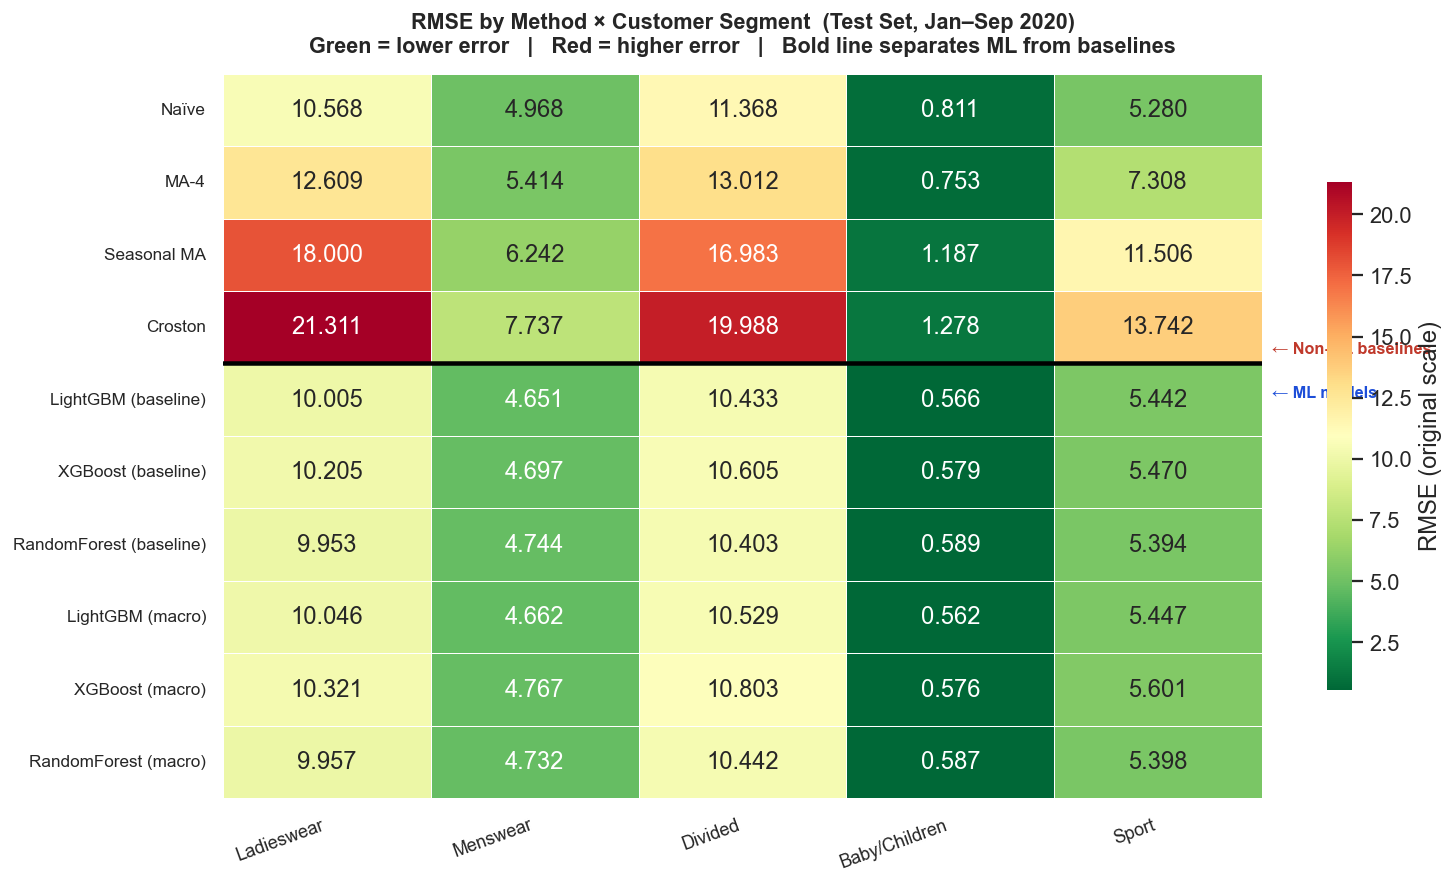

Saved: plots/segments/S1_rmse_heatmap_segment.png


In [11]:
# ── Plot 1: RMSE heatmap — method × segment ───────────────────────────────────
focus_methods_ordered = ['Naïve', 'MA-4', 'Seasonal MA', 'Croston',
                         '— — —',
                         'LightGBM (baseline)', 'XGBoost (baseline)',
                         'RandomForest (baseline)']

heat_data = []
for method in ALL_METHODS:
    row = {'Method': method}
    for seg in SEGMENTS:
        val = seg_df[(seg_df['Method']==method) & (seg_df['segment']==seg)]['RMSE'].values
        row[seg] = val[0] if len(val) else np.nan
    heat_data.append(row)

heat_df = pd.DataFrame(heat_data).set_index('Method')[SEGMENTS]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    heat_df, annot=True, fmt='.3f', cmap='RdYlGn_r',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'RMSE (original scale)', 'shrink': 0.7},
    ax=ax
)

# Draw a horizontal line separating baselines from ML models
ax.axhline(len(BASELINE_METHODS), color='black', linewidth=2.5)
ax.text(len(SEGMENTS) + 0.05, len(BASELINE_METHODS) - 0.1,
        '← Non-ML baselines', va='bottom', ha='left', fontsize=9,
        color='#c0392b', fontweight='bold')
ax.text(len(SEGMENTS) + 0.05, len(BASELINE_METHODS) + 0.3,
        '← ML models', va='top', ha='left', fontsize=9,
        color='#1d4ed8', fontweight='bold')

ax.set_title('RMSE by Method × Customer Segment  (Test Set, Jan–Sep 2020)\n'
             'Green = lower error   |   Red = higher error   |   Bold line separates ML from baselines',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=9.5)
plt.tight_layout()
plt.savefig('plots/segments/S1_rmse_heatmap_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/segments/S1_rmse_heatmap_segment.png')


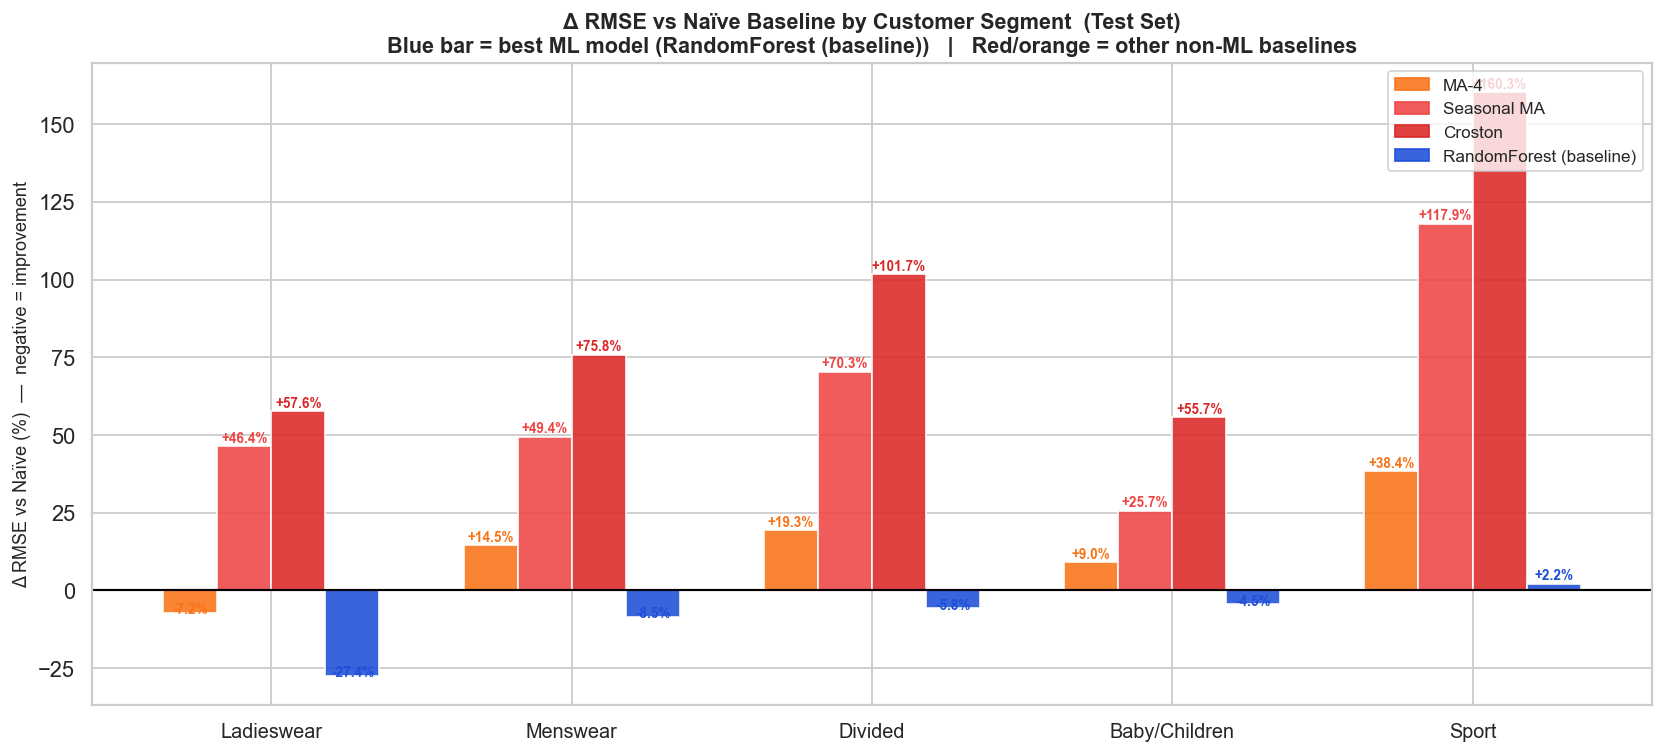

Saved: plots/segments/S2_delta_rmse_by_segment.png


In [12]:
# ── Plot 2: Δ RMSE vs Naïve grouped bar chart — by segment ───────────────────
PLOT_METHODS = ['MA-4', 'Seasonal MA', 'Croston', best_ml_label]
COLORS = {
    'MA-4':          '#f97316',
    'Seasonal MA':   '#ef4444',
    'Croston':       '#dc2626',
    best_ml_label:   '#1d4ed8',
}

delta_pivot = seg_df[seg_df['Method'].isin(PLOT_METHODS)].pivot(
    index='segment', columns='Method', values='Δ RMSE vs Naïve (%)')[PLOT_METHODS]

x   = np.arange(len(SEGMENTS))
w   = 0.18
fig, ax = plt.subplots(figsize=(13, 6))

for i, method in enumerate(PLOT_METHODS):
    offset = (i - 1.5) * w
    bars = ax.bar(x + offset, delta_pivot[method], w,
                  color=COLORS[method], alpha=0.88, edgecolor='white',
                  label=method)
    for bar, val in zip(bars, delta_pivot[method]):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (0.3 if val >= 0 else -1.2),
                    f'{val:+.1f}%', ha='center', va='bottom',
                    fontsize=7.5, fontweight='bold',
                    color=COLORS[method])

ax.axhline(0, color='black', linewidth=1.2)
ax.set_xticks(x)
ax.set_xticklabels(SEGMENTS, fontsize=11)
ax.set_ylabel('Δ RMSE vs Naïve (%)  —  negative = improvement', fontsize=10)
ax.set_title(f'Δ RMSE vs Naïve Baseline by Customer Segment  (Test Set)\n'
             f'Blue bar = best ML model ({best_ml_label})   |   Red/orange = other non-ML baselines',
             fontsize=12, fontweight='bold')

legend_patches = [mpatches.Patch(color=COLORS[m], alpha=0.88, label=m) for m in PLOT_METHODS]
ax.legend(handles=legend_patches, fontsize=9.5, loc='upper right')
plt.tight_layout()
plt.savefig('plots/segments/S2_delta_rmse_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/segments/S2_delta_rmse_by_segment.png')


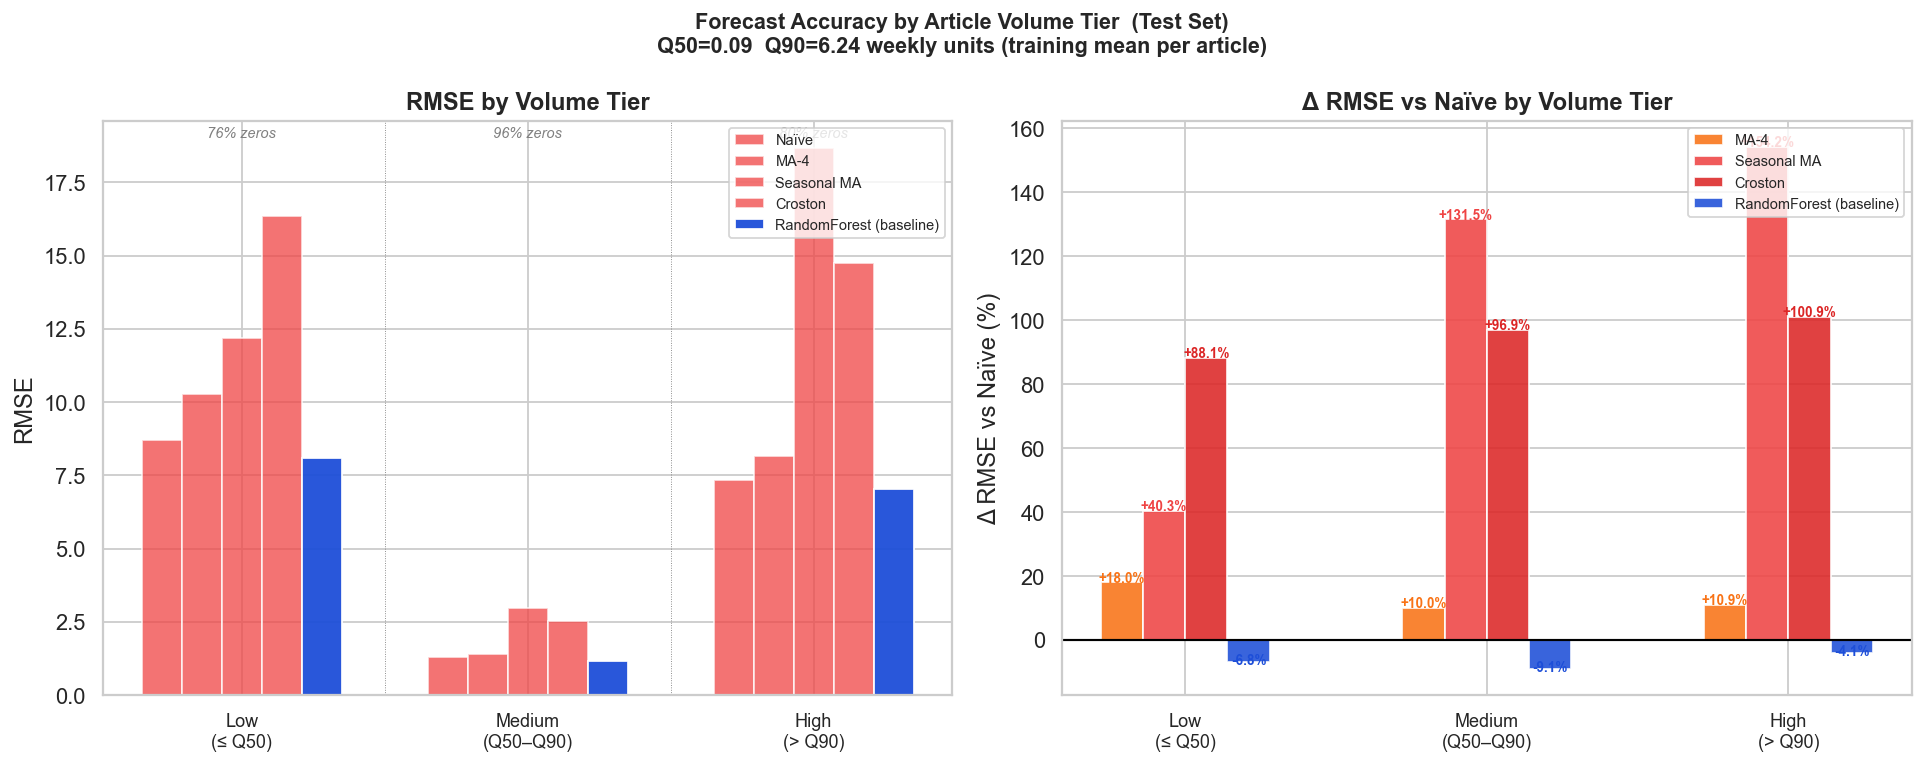

Saved: plots/segments/S3_rmse_by_volume_tier.png


In [13]:
# ── Plot 3: RMSE & Δ RMSE by volume tier ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: absolute RMSE per tier (bar chart, best ML + all baselines)
focus_vol = vol_df[vol_df['Method'].isin(BASELINE_METHODS + [best_ml_label])].copy()
tier_colors = {'Low  (≤ Q50)': '#94a3b8', 'Medium  (Q50–Q90)': '#64748b', 'High  (> Q90)': '#1e293b'}
method_order = BASELINE_METHODS + [best_ml_label]

x = np.arange(len(TIERS)); w = 0.14
for i, method in enumerate(method_order):
    sub  = focus_vol[focus_vol['Method']==method].set_index('volume_tier')['RMSE'].reindex(TIERS)
    clr  = '#1d4ed8' if method == best_ml_label else '#ef4444'
    off  = (i - 2) * w
    bars = axes[0].bar(x + off, sub, w, label=method,
                       color=clr, alpha=0.75 if method != best_ml_label else 0.95,
                       edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(['Low\n(≤ Q50)','Medium\n(Q50–Q90)','High\n(> Q90)'], fontsize=10)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by Volume Tier', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].axvline(0.5, color='grey', linewidth=0.5, linestyle=':')
axes[0].axvline(1.5, color='grey', linewidth=0.5, linestyle=':')

# Right: Δ RMSE vs Naïve for best ML + worst/best baseline
delta_vol = vol_df[vol_df['Method'].isin(PLOT_METHODS)].pivot(
    index='volume_tier', columns='Method', values='Δ RMSE vs Naïve (%)').reindex(TIERS)

for i, method in enumerate(PLOT_METHODS):
    off  = (i - 1.5) * w
    clr  = COLORS[method]
    bars = axes[1].bar(x + off, delta_vol[method], w,
                       color=clr, alpha=0.88, edgecolor='white', label=method)
    for bar, val in zip(bars, delta_vol[method]):
        if not np.isnan(val):
            axes[1].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + (0.1 if val>=0 else -0.8),
                         f'{val:+.1f}%', ha='center', fontsize=7.5,
                         fontweight='bold', color=clr)

axes[1].axhline(0, color='black', linewidth=1.2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Low\n(≤ Q50)','Medium\n(Q50–Q90)','High\n(> Q90)'], fontsize=10)
axes[1].set_ylabel('Δ RMSE vs Naïve (%)')
axes[1].set_title('Δ RMSE vs Naïve by Volume Tier', fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')

# Add zero-% annotation on top
for ax_i, df_i in [(axes[0], vol_df)]:
    for j, tier in enumerate(TIERS):
        zp = df_i[df_i['volume_tier']==tier]['zero_pct'].iloc[0]
        ax_i.text(j, ax_i.get_ylim()[1]*0.97, f'{zp:.0f}% zeros',
                  ha='center', fontsize=8, color='grey', style='italic')

plt.suptitle(f'Forecast Accuracy by Article Volume Tier  (Test Set)\n'
             f'Q50={Q50:.2f}  Q90={Q90:.2f} weekly units (training mean per article)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/segments/S3_rmse_by_volume_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/segments/S3_rmse_by_volume_tier.png')


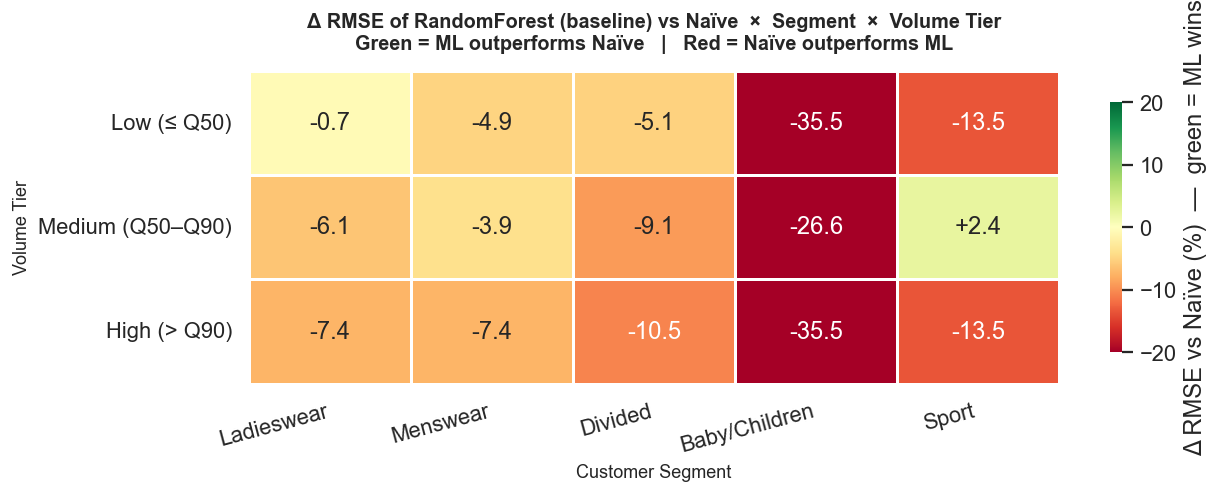

Saved: plots/segments/S4_delta_heatmap_seg_x_tier.png


In [14]:
# ── Plot 4: Δ RMSE heatmap  method × (segment × volume_tier) ─────────────────
# For the best ML vs Naïve only — how improvement varies across both dimensions
ml_vs_naive = master.copy()
ml_vs_naive['ml_pred']    = master[best_ml_label]
ml_vs_naive['naive_pred'] = master['Naïve']

grid_rows = []
for seg in SEGMENTS:
    for tier in TIERS:
        grp = ml_vs_naive[(ml_vs_naive['segment']==seg) &
                          (ml_vs_naive['volume_tier']==tier)]
        if len(grp) < 10:
            continue
        y   = grp['weekly_sales_volume'].values
        r_naive = rmse(y, grp['naive_pred'].values)
        r_ml    = rmse(y, grp['ml_pred'].values)
        delta   = (r_ml - r_naive) / r_naive * 100  # negative = ML wins
        grid_rows.append({
            'Segment':     seg,
            'Volume tier': tier.split('(')[0].strip(),
            'Δ RMSE (%)':  round(delta, 1),
            'n_rows':      len(grp),
        })

grid_df = pd.DataFrame(grid_rows)
heat2 = grid_df.pivot(index='Volume tier', columns='Segment', values='Δ RMSE (%)')[SEGMENTS]

tier_labels = ['Low (≤ Q50)', 'Medium (Q50–Q90)', 'High (> Q90)']
heat2.index = tier_labels

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heat2, annot=True, fmt='+.1f', cmap='RdYlGn',
    center=0, vmin=-20, vmax=20,
    linewidths=0.8, linecolor='white',
    cbar_kws={'label': 'Δ RMSE vs Naïve (%)  —  green = ML wins', 'shrink': 0.8},
    ax=ax
)
ax.set_title(f'Δ RMSE of {best_ml_label} vs Naïve  ×  Segment  ×  Volume Tier\n'
             'Green = ML outperforms Naïve   |   Red = Naïve outperforms ML',
             fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Customer Segment', fontsize=10)
ax.set_ylabel('Volume Tier', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('plots/segments/S4_delta_heatmap_seg_x_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/segments/S4_delta_heatmap_seg_x_tier.png')


In [15]:
# ── Summary table: managerial interpretation ─────────────────────────────────
print('\n' + '='*85)
print('  SEGMENT-LEVEL SUMMARY  —  Δ RMSE of best ML vs Naïve')
print('='*85)
seg_summary = (seg_df[seg_df['Method'] == best_ml_label]
               [['segment', 'RMSE', 'MAE', 'NZ-MAPE (%)', 'Δ RMSE vs Naïve (%)']]
               .sort_values('Δ RMSE vs Naïve (%)'))
print(seg_summary.to_string(index=False))

print('\n' + '='*85)
print('  VOLUME-TIER SUMMARY  —  Δ RMSE of best ML vs Naïve')
print('='*85)
vol_summary = (vol_df[vol_df['Method'] == best_ml_label]
               [['volume_tier', 'n_articles', 'zero_pct', 'RMSE', 'MAE',
                 'NZ-MAPE (%)', 'Δ RMSE vs Naïve (%)']]
               .sort_values('Δ RMSE vs Naïve (%)'))
print(vol_summary.to_string(index=False))

print(f'\nBest ML model used throughout: {best_ml_label}')
print('\nManagerial interpretation notes:')
best_seg = seg_summary.iloc[0]['segment']
worst_seg = seg_summary.iloc[-1]['segment']
best_tier = vol_summary.iloc[0]['volume_tier']
worst_tier = vol_summary.iloc[-1]['volume_tier']
print(f'  • ML gains are largest in {best_seg} (Δ RMSE = {seg_summary.iloc[0]["Δ RMSE vs Naïve (%)"]:.1f}%)')
print(f'  • Smallest ML gain in {worst_seg} (Δ RMSE = {seg_summary.iloc[-1]["Δ RMSE vs Naïve (%)"]:.1f}%)')
print(f'  • ML gains are strongest for {best_tier} articles')
print(f'  • ML weakest for {worst_tier} articles (high intermittency)')



  SEGMENT-LEVEL SUMMARY  —  Δ RMSE of best ML vs Naïve
      segment    RMSE    MAE  NZ-MAPE (%)  Δ RMSE vs Naïve (%)
Baby/Children  0.5888 0.1402        72.41                -27.4
      Divided 10.4026 2.5379        82.41                 -8.5
   Ladieswear  9.9530 2.3047        71.90                 -5.8
     Menswear  4.7442 1.0884        76.54                 -4.5
        Sport  5.3937 0.9852        71.00                  2.2

  VOLUME-TIER SUMMARY  —  Δ RMSE of best ML vs Naïve
      volume_tier  n_articles  zero_pct   RMSE    MAE  NZ-MAPE (%)  Δ RMSE vs Naïve (%)
Medium  (Q50–Q90)        3090      96.5 1.1715 0.1101        63.30                 -9.1
     Low  (≤ Q50)        3995      76.0 8.1066 1.7840        78.82                 -6.8
    High  (> Q90)         788      80.5 7.0456 1.4252        61.62                 -4.1

Best ML model used throughout: RandomForest (baseline)

Managerial interpretation notes:
  • ML gains are largest in Baby/Children (Δ RMSE = -27.4%)
  • Smalle